# Notebook 3: RoBERTa Transfer Learning

Dataset: McAuley-Lab/Amazon-Reviews-2023 — Pet Supplies

This notebook applies `cardiffnlp/twitter-roberta-base-sentiment-latest` as a
zero-shot transfer learning model. It reads from `data/cleaned_reviews_with_preds.csv`
produced by Notebook 2, adds RoBERTa predictions and confidence scores, and saves
the enriched file for Notebook 4. Do not rerun Notebooks 1 or 2 before this.

## 1. Imports & Configuration

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
import joblib

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────
# Reads from Notebook 2 output — do not change this path
PREDS_PATH = Path("data/cleaned_reviews_with_preds.csv")

LABELS      = ["Negative", "Neutral", "Positive"]
LABEL_INT   = {"Negative": 0, "Neutral": 1, "Positive": 2}
INT_LABEL   = {0: "Negative", 1: "Neutral", 2: "Positive"}
RANDOM_SEED = 42

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")


Device : cpu


## 2. Load Data & Recreate Test Split

In [2]:
df = pd.read_csv(PREDS_PATH)
df["sentiment_int"] = df["sentiment_label"].map(LABEL_INT)

X = df["review_text"].fillna("").astype(str)
y = df["sentiment_int"]

# Identical parameters to Notebook 2 — guarantees the same test set
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

print(f"Total records : {len(df):,}")
print(f"Test set size : {len(X_test):,}")
print(f"Test labels   : {pd.Series(y_test).value_counts().to_dict()}")


Total records : 10,000
Test set size : 2,000
Test labels   : {2: 1561, 0: 276, 1: 163}


## 3. Load Pre-trained Model

In [3]:
print(f"Loading {MODEL_NAME} ...")
tokeniser = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model     = model.to(DEVICE)
model.eval()

print("Model label mapping:", model.config.id2label)


Loading cardiffnlp/twitter-roberta-base-sentiment-latest ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}


## 4. Inference

In [4]:
def predict_roberta(texts, tokeniser, model, device,
                    batch_size=32, max_length=512):
    """
    Batched inference. Returns predicted class indices and probability arrays.
    max_length=512 matches RoBERTa's context window; reviews exceeding this
    are truncated from the right (rare given median length of ~31 words).
    """
    all_preds, all_probs = [], []

    for i in tqdm(range(0, len(texts), batch_size), desc="Inference"):
        batch = list(texts[i: i + batch_size])
        enc   = tokeniser(batch, return_tensors="pt", padding=True,
                          truncation=True, max_length=max_length)
        enc   = {k: v.to(device) for k, v in enc.items()}

        with torch.no_grad():
            logits = model(**enc).logits.cpu().numpy()

        probs = softmax(logits, axis=1)
        all_preds.extend(probs.argmax(axis=1).tolist())
        all_probs.extend(probs.tolist())

    return np.array(all_preds), np.array(all_probs)


# ── Align model indices to project label schema ────────────────────────────
remap = {}
for model_idx, label_str in model.config.id2label.items():
    our_int = LABEL_INT.get(label_str.capitalize())
    if our_int is not None:
        remap[int(model_idx)] = our_int
print("Index remap (model → project):", remap)

# Run inference on test set for evaluation
test_texts               = X_test.reset_index(drop=True)
raw_preds_test, raw_probs_test = predict_roberta(
    test_texts, tokeniser, model, DEVICE)
y_pred_roberta = np.array([remap.get(p, p) for p in raw_preds_test])
print("\nTest inference complete.")


Index remap (model → project): {0: 0, 1: 1, 2: 2}


Inference:   0%|          | 0/63 [00:00<?, ?it/s]


Test inference complete.


## 5. Evaluation

In [5]:
print("CLASSIFICATION REPORT — RoBERTa (zero-shot transfer)")
print("=" * 55)
print(classification_report(y_test.values, y_pred_roberta,
                             target_names=LABELS, zero_division=0))

macro_f1_rob    = f1_score(y_test, y_pred_roberta, average="macro",    zero_division=0)
weighted_f1_rob = f1_score(y_test, y_pred_roberta, average="weighted", zero_division=0)
acc_rob         = accuracy_score(y_test, y_pred_roberta)

print(f"Macro F1    : {macro_f1_rob:.4f}")
print(f"Weighted F1 : {weighted_f1_rob:.4f}")
print(f"Accuracy    : {acc_rob:.4f}")


CLASSIFICATION REPORT — RoBERTa (zero-shot transfer)
              precision    recall  f1-score   support

    Negative       0.59      0.81      0.69       276
     Neutral       0.19      0.18      0.19       163
    Positive       0.95      0.89      0.92      1561

    accuracy                           0.82      2000
   macro avg       0.58      0.63      0.60      2000
weighted avg       0.84      0.82      0.83      2000

Macro F1    : 0.5974
Weighted F1 : 0.8279
Accuracy    : 0.8230


### 5.1 Confusion Matrix

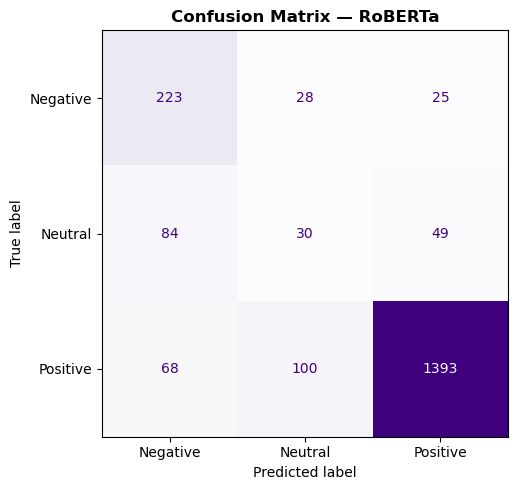

In [6]:
cm = confusion_matrix(y_test, y_pred_roberta)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS).plot(
    ax=ax, colorbar=False, cmap="Purples")
ax.set_title("Confusion Matrix — RoBERTa", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("data/fig_cm_roberta.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.2 Prediction Confidence Distribution

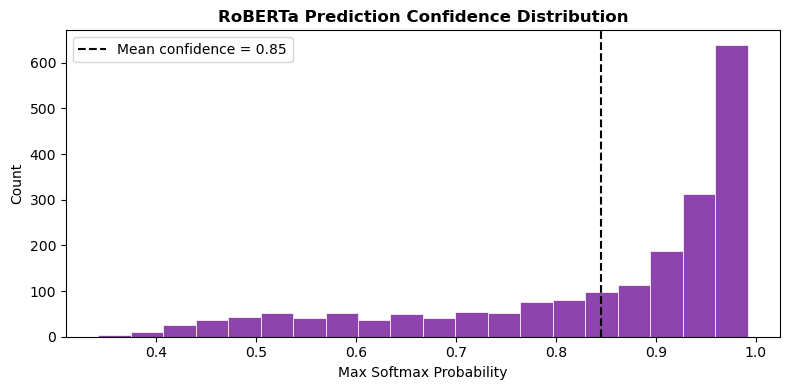

In [7]:
max_probs = raw_probs_test.max(axis=1)
fig, ax   = plt.subplots(figsize=(8, 4))
ax.hist(max_probs, bins=20, color="#8E44AD", edgecolor="white", linewidth=0.5)
ax.axvline(max_probs.mean(), linestyle="--", color="black",
           label=f"Mean confidence = {max_probs.mean():.2f}")
ax.set_title("RoBERTa Prediction Confidence Distribution",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Max Softmax Probability")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("data/fig_roberta_confidence.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Model Comparison

In [8]:
# Load TF-IDF results from Notebook 2 for direct comparison
pipeline_tfidf  = joblib.load("models/tfidf_logreg.pkl")
y_pred_tfidf    = pipeline_tfidf.predict(X_test)
macro_f1_tfidf  = f1_score(y_test, y_pred_tfidf, average="macro", zero_division=0)
acc_tfidf       = accuracy_score(y_test, y_pred_tfidf)

comparison = pd.DataFrame({
    "Model"              : ["TF-IDF + Logistic Regression", "RoBERTa (zero-shot)"],
    "Macro F1"           : [round(macro_f1_tfidf, 4),  round(macro_f1_rob, 4)],
    "Accuracy"           : [round(acc_tfidf, 4),        round(acc_rob, 4)],
    "Requires training?" : ["Yes", "No (zero-shot)"],
    "Interpretable?"     : ["Yes", "Limited"],
    "Handles context?"   : ["No",  "Yes"],
})
print(comparison.to_string(index=False))
comparison.to_csv("data/model_comparison.csv", index=False)
print("\nComparison saved → data/model_comparison.csv")


                       Model  Macro F1  Accuracy Requires training? Interpretable? Handles context?
TF-IDF + Logistic Regression    0.6678    0.8335                Yes            Yes               No
         RoBERTa (zero-shot)    0.5974    0.8230     No (zero-shot)        Limited              Yes

Comparison saved → data/model_comparison.csv


## 6. Run Full-Dataset Inference & Save

In [9]:
# Run RoBERTa on the entire dataset — predictions feed Notebook 4
print("Running full-dataset inference ...")
all_texts              = df["review_text"].fillna("").astype(str).reset_index(drop=True)
all_raw_preds, all_raw_probs = predict_roberta(
    all_texts, tokeniser, model, DEVICE)

df["roberta_pred_int"]      = [remap.get(p, p) for p in all_raw_preds]
df["roberta_pred_label"]    = df["roberta_pred_int"].map(INT_LABEL)
df["roberta_confidence"]    = all_raw_probs.max(axis=1)
df["roberta_prob_negative"] = all_raw_probs[:, remap.get(0, 0)]
df["roberta_prob_neutral"]  = all_raw_probs[:, remap.get(1, 1)]
df["roberta_prob_positive"] = all_raw_probs[:, remap.get(2, 2)]

df.to_csv(PREDS_PATH, index=False)
print(f"Full predictions saved → {PREDS_PATH}")

print()
print("FINAL MODEL SELECTED: RoBERTa")
print(f"  RoBERTa Macro F1  : {macro_f1_rob:.4f}")
print(f"  TF-IDF  Macro F1  : {macro_f1_tfidf:.4f}")
print("  Justification: superior contextual understanding, zero-shot")
print("  capability, better handling of negation and short informal text.")


Running full-dataset inference ...


Inference:   0%|          | 0/313 [00:00<?, ?it/s]

Full predictions saved → data\cleaned_reviews_with_preds.csv

FINAL MODEL SELECTED: RoBERTa
  RoBERTa Macro F1  : 0.5974
  TF-IDF  Macro F1  : 0.6678
  Justification: superior contextual understanding, zero-shot
  capability, better handling of negation and short informal text.
